This notebook reproduces all main and appendix figures, tables, and timing results for the Deceptron architecture (while DeceptronNet is given seperately)

In [ ]:
# Determinism / seeds
import os, random, numpy as np, torch

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"  # or ":4096:8"; required for CUDA determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=False)

BASE_SEED = 0
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BASE_SEED)


In [ ]:
import os, json, time, random, math, inspect
from dataclasses import dataclass, asdict
from typing import Tuple, Dict, Callable, Optional

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


@dataclass
class GlobalConfig:
    out_dir: str = "outputs_fair"
    seed: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    dtype: torch.dtype = torch.float32

    # training
    epochs: int = 60
    batch_size: int = 128
    lr: float = 5e-4
    grad_clip: float = 0.5

    # loss weights
    w_task: float = 1.0
    w_rec: float = 0.1
    w_cyc: float = 0.05
    w_spec: float = 1e-6
    w_soft_tie: float = 1e-4
    w_comp: float = 1e-3

    # JCP
    w_jcp_start: float = 0.0
    w_jcp_max: float = 1e-3
    jcp_probes: int = 2
    jcp_trigger_linear: float = 7e-2
    jcp_trigger_nonlinear: float = 0.6
    jcp_warmup_start_frac: float = 0.20
    jcp_warmup_end_frac: float = 0.80

    # activation
    activation: str = "linear"
    leak: float = 0.1

    # Heat-1D data
    heat1d_N: int = 64
    heat1d_kappa: float = 1.0
    heat1d_noise: float = 0.02
    heat1d_s: float = 0.45
    heat1d_Tsteps: int = 200
    heat1d_train: int = 5000
    heat1d_val: int = 500
    heat1d_test: int = 500

    # oscillator data
    osc_M: int = 64
    osc_T: float = 5.0
    osc_noise: float = 0.01
    m_range: Tuple[float, float] = (0.5, 2.0)
    k_range: Tuple[float, float] = (0.5, 5.0)
    c_range: Tuple[float, float] = (0.0, 1.0)
    x0_range: Tuple[float, float] = (-2.0, 2.0)
    v0_range: Tuple[float, float] = (-2.0, 2.0)

    # solver / fairness
    max_iters: int = 200
    eps_norm: float = 0.30
    backtrack_c: float = 1e-4
    backtrack_halvings: int = 8
    relax_rho: float = 0.4

    eta_xgd: float = 1.0
    alpha_dipg: float = 1.0
    alpha_gn: float = 1.0

    rmse_tol: float = 1e-4
    stall_patience: int = 20

    use_rec: bool = True
    use_cyc: bool = True
    use_spectral: bool = True
    use_soft_tie: bool = True
    use_jcp: bool = True
    learn_V: bool = True

    ridge_lambda: float = 1e-4


CFG = GlobalConfig()


def set_seed(s: int):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


def ensure_out_dir():
    for d in [
        CFG.out_dir,
        f"{CFG.out_dir}/tables",
        f"{CFG.out_dir}/appendix",
    ]:
        os.makedirs(d, exist_ok=True)


def print_config():
    print("CONFIG ===")
    for k, v in asdict(CFG).items():
        print(f"{k}: {v}")


set_seed(CFG.seed)
ensure_out_dir()
print_config()


CONFIG ===
out_dir: outputs_fair
seed: 0
device: cpu
dtype: torch.float32
epochs: 60
batch_size: 128
lr: 0.0005
grad_clip: 0.5
w_task: 1.0
w_rec: 0.1
w_cyc: 0.05
w_spec: 1e-06
w_soft_tie: 0.0001
w_comp: 0.001
w_jcp_start: 0.0
w_jcp_max: 0.001
jcp_probes: 2
jcp_trigger_linear: 0.07
jcp_trigger_nonlinear: 0.6
jcp_warmup_start_frac: 0.2
jcp_warmup_end_frac: 0.8
activation: linear
leak: 0.1
heat1d_N: 64
heat1d_kappa: 1.0
heat1d_noise: 0.02
heat1d_s: 0.45
heat1d_Tsteps: 200
heat1d_train: 5000
heat1d_val: 500
heat1d_test: 500
osc_M: 64
osc_T: 5.0
osc_noise: 0.01
m_range: (0.5, 2.0)
k_range: (0.5, 5.0)
c_range: (0.0, 1.0)
x0_range: (-2.0, 2.0)
v0_range: (-2.0, 2.0)
max_iters: 200
eps_norm: 0.3
backtrack_c: 0.0001
backtrack_halvings: 8
relax_rho: 0.4
eta_xgd: 1.0
alpha_dipg: 1.0
alpha_gn: 1.0
rmse_tol: 0.0001
stall_patience: 20
use_rec: True
use_cyc: True
use_spectral: True
use_soft_tie: True
use_jcp: True
learn_V: True
ridge_lambda: 0.0001


In [ ]:
class ZNormalizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, Y: torch.Tensor):
        self.mean = Y.mean(0, keepdim=True)
        self.std = Y.std(0, unbiased=False, keepdim=True).clamp_min(1e-8)

    def transform(self, Y):
        return (Y - self.mean) / self.std

    def inverse(self, Yn):
        return Yn * self.std + self.mean


# ---- Heat-1D
def _synth_ic_1d(N, max_freq=12):
    x = np.linspace(0, 1, N)
    u0 = np.zeros_like(x)
    coeffs = np.random.normal(0.0, 0.5, size=max_freq)
    for k in range(1, max_freq + 1):
        u0 += coeffs[k - 1] * np.sin(math.pi * k * x)
    u0 = np.clip(u0, -3.0, 3.0)
    u0[0] = 0.0
    u0[-1] = 0.0
    return u0


def _heat1d_sim(u0, s, Tsteps, kappa=1.0):
    N = len(u0)
    traj = np.zeros((Tsteps + 1, N), dtype=np.float64)
    traj[0] = u0
    for t in range(Tsteps):
        u = traj[t]
        un = u.copy()
        un[1:-1] = u[1:-1] + s * (u[2:] - 2 * u[1:-1] + u[:-2])
        un[0] = 0.0
        un[-1] = 0.0
        traj[t + 1] = un
    return traj


def make_heat1d_dataset():
    N, T, s, noise = CFG.heat1d_N, CFG.heat1d_Tsteps, CFG.heat1d_s, CFG.heat1d_noise

    def gen(n):
        X, Y = [], []
        for _ in range(n):
            u0 = _synth_ic_1d(N)
            traj = _heat1d_sim(u0, s, T, CFG.heat1d_kappa)
            y = traj[-1] + np.random.normal(0.0, noise, size=(N,))
            X.append(u0.astype(np.float32))
            Y.append(y.astype(np.float32))
        return torch.tensor(np.stack(X)), torch.tensor(np.stack(Y))

    Xtr, Ytr = gen(CFG.heat1d_train)
    Xva, Yva = gen(CFG.heat1d_val)
    Xte, Yte = gen(CFG.heat1d_test)
    nz = ZNormalizer()
    nz.fit(Ytr)
    Ytrn, Yvan, Yten = nz.transform(Ytr), nz.transform(Yva), nz.transform(Yte)
    print(f"[Heat-1D] N={N}, T={T}, s={s} (≤0.5 good)")
    return {
        "train": (Xtr, Ytrn),
        "val": (Xva, Yvan),
        "test": (Xte, Yten),
        "normalizer": nz,
        "raw": {"Ytr": Ytr, "Yva": Yva, "Yte": Yte},
    }


# ---- Oscillator
def _rk4_step(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def _osc_sim(theta, T, M):
    m, c, k, x0, v0 = theta

    def f(t, y):
        x, v = y
        return np.array([v, -(c / m) * v - (k / m) * x], dtype=np.float64)

    ts = np.linspace(0.0, T, M)
    dt = ts[1] - ts[0]
    y = np.array([x0, v0], dtype=np.float64)
    X = np.zeros(M, dtype=np.float64)
    for i, t in enumerate(ts):
        X[i] = y[0]
        if i < M - 1:
            y = _rk4_step(f, t, y, dt)
    return X


def _sample_theta():
    m = np.random.uniform(*CFG.m_range)
    k = np.random.uniform(*CFG.k_range)
    c = np.random.uniform(*CFG.c_range)
    x0 = np.random.uniform(*CFG.x0_range)
    v0 = np.random.uniform(*CFG.v0_range)
    return np.array([m, c, k, x0, v0], dtype=np.float64)


def make_osc_dataset():
    M, T, noise = CFG.osc_M, CFG.osc_T, CFG.osc_noise

    def gen(n):
        X, Y = [], []
        for _ in range(n):
            th = _sample_theta()
            traj = _osc_sim(th, T, M)
            y = traj + np.random.normal(0.0, noise, size=traj.shape)
            X.append(th.astype(np.float32))
            Y.append(y.astype(np.float32))
        return torch.tensor(np.stack(X)), torch.tensor(np.stack(Y))

    Xtr, Ytr = gen(CFG.heat1d_train)
    Xva, Yva = gen(CFG.heat1d_val)
    Xte, Yte = gen(CFG.heat1d_test)
    nz = ZNormalizer()
    nz.fit(Ytr)
    Ytrn, Yvan, Yten = nz.transform(Ytr), nz.transform(Yva), nz.transform(Yte)
    print(f"[Osc] M={M}, T={T}, noise={noise}")
    return {
        "train": (Xtr, Ytrn),
        "val": (Xva, Yvan),
        "test": (Xte, Yten),
        "normalizer": nz,
        "raw": {"Ytr": Ytr, "Yva": Yva, "Yte": Yte},
    }


In [ ]:
class MirrorLeaky(nn.Module):
    def __init__(self, negative_slope=0.1):
        super().__init__()
        self.a = negative_slope

    def forward(self, y):
        a = self.a
        return torch.where(y >= 0, y, y / a)


class IdentityAct(nn.Module):
    def forward(self, x):
        return x


class Deceptron(nn.Module):
    def __init__(self, in_dim, out_dim, activation="linear", leak=0.1, learn_V=True):
        super().__init__()
        self.in_dim, self.out_dim, self.learn_V = in_dim, out_dim, learn_V

        self.W = nn.Parameter(torch.empty(out_dim, in_dim))
        nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))
        self.b = nn.Parameter(torch.zeros(out_dim))
        self.c = nn.Parameter(torch.zeros(in_dim))

        if learn_V:
            self.V = nn.Parameter(torch.empty(in_dim, out_dim))
            nn.init.kaiming_uniform_(self.V, a=math.sqrt(5))
        else:
            self.register_parameter("V", None)

        if activation == "leaky":
            self.sigma = nn.LeakyReLU(CFG.leak)
            self.sigma_mirror = MirrorLeaky(CFG.leak)
        else:
            self.sigma = IdentityAct()
            self.sigma_mirror = IdentityAct()

    def f(self, x):
        return self.sigma(F.linear(x, self.W, self.b))

    def g(self, y):
        lin = F.linear(y, self.V if (self.learn_V and self.V is not None) else self.W.t(), self.c)
        return self.sigma_mirror(lin)

    def spectral_penalty(self):
        I = torch.eye(self.in_dim, device=self.W.device, dtype=self.W.dtype)
        G = self.W.t() @ self.W
        return ((G - I) ** 2).mean()


# ---- JVP helper and JCP penalty
def _jvp(func, x_tup, v_tup):
    try:
        y, jv = torch.autograd.functional.jvp(func, x_tup, v_tup, create_graph=True, strict=True)
        return y, jv
    except Exception:
        eps = 1e-3
        y0 = func(*x_tup)
        y1 = func(*tuple(x + eps * v for x, v in zip(x_tup, v_tup)))
        return y0, (y1 - y0) / eps


def jcp_penalty(model: Deceptron, x: torch.Tensor, probes: int = 2, detach_forward: bool = False):
    B, D = x.shape
    dev = x.device
    total = 0.0

    f = lambda t: model.f(t)
    g = lambda t: model.g(t)

    for _ in range(probes):
        xi = torch.randn(B, D, device=dev, dtype=x.dtype)
        xin = x.detach() if detach_forward else x
        _, jf_xi = _jvp(f, (xin,), (xi,))

        y = f(x)
        yin = y.detach().requires_grad_(True) if detach_forward else y
        _, jg_jf_xi = _jvp(g, (yin,), (jf_xi.detach() if detach_forward else jf_xi,))

        total = total + (jg_jf_xi - xi).pow(2).sum(dim=1).mean()

    return total / float(probes)


In [ ]:
@torch.no_grad()
def _ridge_prefit_W(X: torch.Tensor, Y: torch.Tensor, lam: float) -> torch.Tensor:
    Xn = X.cpu().numpy()
    Yn = Y.cpu().numpy()
    d_in = Xn.shape[1]
    W = (Yn.T @ Xn) @ np.linalg.inv(Xn.T @ Xn + lam * np.eye(d_in))
    return torch.tensor(W, dtype=X.dtype)


def train_deceptron(task_name: str, train, val, in_dim: int, out_dim: int,
                    learn_V=True, activation=None, leak=None, detach_jcp_forward=False):
    device = CFG.device
    activation = CFG.activation if activation is None else activation
    leak = CFG.leak if leak is None else leak

    model = Deceptron(in_dim, out_dim, activation=activation, leak=leak, learn_V=learn_V).to(device)

    Xtr, Ytr = (train[0].to(device), train[1].to(device))
    Xva, Yva = (val[0].to(device), val[1].to(device))

    with torch.no_grad():
        model.W.copy_(_ridge_prefit_W(Xtr, Ytr, lam=CFG.ridge_lambda).to(device))
        model.b.zero_()
        model.c.zero_()
        if model.learn_V and model.V is not None:
            W = model.W.detach()
            WtW = (W.t() @ W).cpu().numpy()
            V = np.linalg.inv(WtW + CFG.ridge_lambda * np.eye(WtW.shape[0])) @ W.cpu().numpy().T
            model.V.copy_(torch.tensor(V, dtype=model.W.dtype, device=device))

    opt = torch.optim.Adam(model.parameters(), lr=CFG.lr)
    dl = DataLoader(TensorDataset(Xtr, Ytr), batch_size=CFG.batch_size, shuffle=True)

    logs = {"val_mse": [], "jcp": [], "spec": []}
    jcp_w = CFG.w_jcp_start if CFG.use_jcp else 0.0
    s_e = int(CFG.jcp_warmup_start_frac * CFG.epochs)
    e_e = max(s_e + 1, int(CFG.jcp_warmup_end_frac * CFG.epochs))
    trigger = CFG.jcp_trigger_linear if activation == "linear" else CFG.jcp_trigger_nonlinear

    for ep in range(CFG.epochs):
        model.train()
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)

            yhat = model.f(xb)
            l_task = F.mse_loss(yhat, yb)
            l_rec = F.mse_loss(model.g(yhat), xb) if CFG.use_rec else 0.0
            l_cyc = F.mse_loss(model.f(model.g(yb)), yb) if CFG.use_cyc else 0.0
            l_spec = model.spectral_penalty() if CFG.use_spectral else 0.0
            l_tie = (
                F.mse_loss(model.b, -model.c)
                if model.out_dim == model.in_dim
                else (model.b.pow(2).mean() + model.c.pow(2).mean())
            ) if CFG.use_soft_tie else 0.0
            l_comp = (
                ((model.V @ model.W - torch.eye(model.in_dim, device=device, dtype=model.W.dtype)) ** 2).mean()
                if (model.learn_V and model.V is not None)
                else 0.0
            )
            l_jcp = (
                jcp_penalty(model, xb, probes=CFG.jcp_probes, detach_forward=detach_jcp_forward)
                if (CFG.use_jcp and jcp_w > 0.0)
                else 0.0
            )

            loss = (
                CFG.w_task * l_task
                + CFG.w_rec * l_rec
                + CFG.w_cyc * l_cyc
                + CFG.w_spec * l_spec
                + CFG.w_soft_tie * l_tie
                + CFG.w_comp * l_comp
                + jcp_w * l_jcp
            )

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            opt.step()

        # validation and JCP warmup schedule
        model.eval()
        with torch.no_grad():
            val_mse = F.mse_loss(model.f(Xva), Yva).item()
            logs["val_mse"].append(val_mse)
            logs["spec"].append(model.spectral_penalty().item() if CFG.use_spectral else 0.0)
            if CFG.use_jcp:
                idx = torch.randperm(Xva.shape[0])[:min(64, Xva.shape[0])]
                logs["jcp"].append(jcp_penalty(model, Xva[idx], probes=1).item())

        if CFG.use_jcp and (val_mse < trigger) and (ep >= s_e):
            t = (ep - s_e) / (e_e - s_e)
            t = max(0.0, min(1.0, t))
            jcp_w = CFG.w_jcp_max * (0.2 + 0.8 * t)

        if (ep + 1) % 10 == 0:
            print(f"[{task_name} ep {ep + 1:03d}] val_mse={val_mse:.4e} jcp_w={jcp_w:.2e}")

    return model, logs


In [ ]:
class Projector:
    def __init__(self, task): self.task=task
    def project(self, x: torch.Tensor):
        if self.task=="heat1d":
            x = x.clone()
            x = x.clamp(-3.0,3.0)
            x[...,0]=0.0; x[...,-1]=0.0
            return x
        if self.task=="osc":
            x=x.clone()
            mmin,mmax=CFG.m_range; kmin,kmax=CFG.k_range; cmin,cmax=CFG.c_range
            x0min,x0max=CFG.x0_range; v0min,v0max=CFG.v0_range
            x[...,0]=x[...,0].clamp(mmin,mmax); x[...,2]=x[...,2].clamp(kmin,kmax)
            x[...,1]=x[...,1].clamp(cmin,cmax); x[...,3]=x[...,3].clamp(x0min,x0max); x[...,4]=x[...,4].clamp(v0min,v0max)
            return x
        return x

def forward_loss(model: Deceptron, x_n: torch.Tensor, y_tn: torch.Tensor) -> torch.Tensor:
    diff = model.f(x_n) - y_tn
    return 0.5 * diff.pow(2).mean()


In [ ]:
@torch.no_grad()
def _armijo(model, x, ytn, projector, p_from_alpha:Callable[[float],torch.Tensor],
            grad_at_x:torch.Tensor, alpha0:float, rho:float, c:float, max_halvings:int):
    loss_old = forward_loss(model, x, ytn)
    alpha = alpha0; accepted=False
    for _ in range(max_halvings):
        p = p_from_alpha(alpha)
        if not torch.isfinite(p).all(): alpha *= 0.5; continue
        x_trial = projector.project(x + p)
        x_next  = (1-rho)*x + rho*x_trial
        loss_new = forward_loss(model, x_next, ytn)
        gd = (grad_at_x * p).sum()
        if loss_new <= loss_old + c*rho*gd:
            x = x_next; accepted=True; break
        alpha *= 0.5
    return x.detach(), accepted, alpha

def run_xgd(model, x0, ytn, projector:Projector, max_iters:int, eta:float, rho:float) -> Dict:
    x = projector.project(x0.clone())
    rmse_hist, acc, ts = [], [], []; start=time.perf_counter(); stall=0
    for _ in range(max_iters):
        x_req = x.detach().clone().requires_grad_(True)
        with torch.enable_grad():
            loss = forward_loss(model, x_req, ytn); (grad_x,) = torch.autograd.grad(loss, x_req)
        p_fn = lambda a: -a * grad_x.detach()
        x, ok, _ = _armijo(model, x, ytn, projector, p_fn, grad_x.detach(), eta, CFG.relax_rho, CFG.backtrack_c, CFG.backtrack_halvings)
        acc.append(1 if ok else 0)
        with torch.no_grad():
            rmse = torch.sqrt(F.mse_loss(model.f(x), ytn)).item()
            stall = stall + 1 if (rmse_hist and abs(rmse_hist[-1]-rmse)<CFG.rmse_tol) else 0
            rmse_hist.append(rmse); ts.append(time.perf_counter()-start)
            if stall>=CFG.stall_patience: break
    return {"x_final":x, "rmse_hist":rmse_hist, "accept_hist":acc, "times":ts}

def run_dipg(model, x0, ytn, projector:Projector, max_iters:int, alpha:float, rho:float) -> Dict:
    x = projector.project(x0.clone())
    rmse_hist, acc, ts = [], [], []; start=time.perf_counter(); stall=0
    for _ in range(max_iters):
        x_req = x.detach().clone().requires_grad_(True)
        with torch.enable_grad():
            loss = forward_loss(model, x_req, ytn); (grad_x,) = torch.autograd.grad(loss, x_req)
        with torch.no_grad():
            y = model.f(x); r = y - ytn
        def p_fn(a:float):
            with torch.no_grad():
                y_step = y - a*r
                x_prop = model.g(y_step)
                return x_prop - x
        x, ok, _ = _armijo(model, x, ytn, projector, p_fn, grad_x.detach(), alpha, CFG.relax_rho, CFG.backtrack_c, CFG.backtrack_halvings)
        acc.append(1 if ok else 0)
        with torch.no_grad():
            rmse = torch.sqrt(F.mse_loss(model.f(x), ytn)).item()
            stall = stall + 1 if (rmse_hist and abs(rmse_hist[-1]-rmse)<CFG.rmse_tol) else 0
            rmse_hist.append(rmse); ts.append(time.perf_counter()-start)
            if stall>=CFG.stall_patience: break
    return {"x_final":x, "rmse_hist":rmse_hist, "accept_hist":acc, "times":ts}

@torch.no_grad()
def _vjp(f, x, u):
    with torch.enable_grad():
        t = x.detach().clone().requires_grad_(True); y=f(t); out=(y*u).sum()
        (jt_u,) = torch.autograd.grad(out, t)
    return jt_u

def _cg(matvec, b, iters=8, tol=1e-6):
    x=torch.zeros_like(b); r=b-matvec(x); p=r.clone(); rs=(r.flatten()@r.flatten())
    for _ in range(iters):
        Ap=matvec(p); denom=(p.flatten()@Ap.flatten()).clamp_min(1e-12)
        a=rs/denom; x=x+a*p; r=r-a*Ap; rsn=(r.flatten()@r.flatten())
        if torch.sqrt(rsn)<tol: break
        p=r + (rsn/rs)*p; rs=rsn
    return x

def run_gn(model, x0, ytn, projector:Projector, max_iters:int, alpha:float, rho:float, lam=1e-3, cg_iters=8) -> Dict:
    x = projector.project(x0.clone().to(CFG.device))
    rmse_hist, acc, ts = [], [], []; start=time.perf_counter(); stall=0
    for _ in range(max_iters):
        x_req = x.detach().clone().requires_grad_(True)
        with torch.enable_grad():
            loss = forward_loss(model, x_req, ytn); (grad_x,) = torch.autograd.grad(loss, x_req)

        with torch.enable_grad():
            y = model.f(x); r = (y - ytn).detach()
            b = _vjp(lambda t: model.f(t), x, r)
            def AtA_mv(v):
                _, Jv = torch.autograd.functional.jvp(lambda t: model.f(t), (x,), (v,), create_graph=False)
                return _vjp(lambda t: model.f(t), x, Jv) + lam*v
        with torch.no_grad():
            dx = _cg(AtA_mv, -b.detach(), iters=cg_iters, tol=1e-6)

        p_fn = lambda a: a*dx
        x, ok, _ = _armijo(model, x, ytn, projector, p_fn, grad_x.detach(), alpha, CFG.relax_rho, CFG.backtrack_c, CFG.backtrack_halvings)
        acc.append(1 if ok else 0)
        with torch.no_grad():
            rmse = torch.sqrt(F.mse_loss(model.f(x), ytn)).item()
            stall = stall + 1 if (rmse_hist and abs(rmse_hist[-1]-rmse)<CFG.rmse_tol) else 0
            rmse_hist.append(rmse); ts.append(time.perf_counter()-start)
            if stall>=CFG.stall_patience: break
    return {"x_final":x, "rmse_hist":rmse_hist, "accept_hist":acc, "times":ts}


In [ ]:
def iterations_to_eps(hist, eps):
    for i,r in enumerate(hist):
        if r<=eps: return i+1
    return len(hist)

def eval_task(task:str, model:Deceptron, Xte, Yten, normalizer:ZNormalizer, seeds=[0,1], projector=None, do_gn=True) -> Dict:
    device = CFG.device; projector = projector or Projector(task)
    idx_all = torch.randperm(Xte.shape[0])[:20]
    res = {"xgd":[], "dipg":[]};
    if do_gn: res["gn"]=[]
    for sd in seeds:
        set_seed(sd)
        for idx in idx_all:
            x_true = Xte[idx:idx+1].to(device); y_star = Yten[idx:idx+1].to(device)
            if task=="heat1d":
                x0 = torch.zeros_like(x_true)
            else:
                m0=sum(CFG.m_range)/2; c0=sum(CFG.c_range)/2; k0=sum(CFG.k_range)/2
                x0i=sum(CFG.x0_range)/2; v0i=sum(CFG.v0_range)/2
                x0 = torch.tensor([[m0,c0,k0,x0i,v0i]], dtype=x_true.dtype, device=device)

            out_x = run_xgd(model, x0, y_star, projector, CFG.max_iters, CFG.eta_xgd, CFG.relax_rho)
            out_k = run_dipg(model, x0, y_star, projector, CFG.max_iters, CFG.alpha_dipg, CFG.relax_rho)
            if do_gn: out_g = run_gn(model, x0, y_star, projector, CFG.max_iters, CFG.alpha_gn, CFG.relax_rho)

            def _final_rmse_un(out):
                with torch.no_grad():
                    y_pred_un = normalizer.inverse(model.f(out["x_final"]).detach().cpu()).numpy()
                    y_true_un = normalizer.inverse(y_star.detach().cpu()).numpy()
                    return float(np.sqrt(np.mean((y_pred_un - y_true_un)**2)))

            res["xgd"].append({"rmse_hist":out_x["rmse_hist"], "iters_eps":iterations_to_eps(out_x["rmse_hist"], CFG.eps_norm),
                               "accept_hist":out_x["accept_hist"], "final_rmse_un":_final_rmse_un(out_x), "times":out_x["times"]})
            res["dipg"].append({"rmse_hist":out_k["rmse_hist"], "iters_eps":iterations_to_eps(out_k["rmse_hist"], CFG.eps_norm),
                                "accept_hist":out_k["accept_hist"], "final_rmse_un":_final_rmse_un(out_k), "times":out_k["times"]})
            if do_gn:
                res["gn"].append({"rmse_hist":out_g["rmse_hist"], "iters_eps":iterations_to_eps(out_g["rmse_hist"], CFG.eps_norm),
                                  "accept_hist":out_g["accept_hist"], "final_rmse_un":_final_rmse_un(out_g), "times":out_g["times"]})
    def summarize(m):
        it=[r["iters_eps"] for r in res[m]]; acc=[np.mean(r["accept_hist"]) for r in res[m]]; fm=[r["final_rmse_un"] for r in res[m]]
        return {"iters_mean":float(np.mean(it)), "iters_std":float(np.std(it)), "accept_mean":float(np.mean(acc)), "final_rmse_mean":float(np.mean(fm))}
    return {"per_item":res, "summary":{m:summarize(m) for m in res}}


Figure generation (used in paper)  



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

PAL = {"xgd": "#ff7f0e", "dipg": "#1f77b4", "gn": "#2ca02c", "init": "#000000"}
LAB = {"xgd": "x-GD", "dipg": "D-IPG", "gn": "GN/LM"}

def _ensure(p):
    os.makedirs(p, exist_ok=True)
    return p

def _iters_to_eps_local(hist, eps):
    for i, r in enumerate(hist):
        if r <= eps:
            return i
    return len(hist) - 1

def _mean_curve(rmse_lists):
    L = max(len(a) for a in rmse_lists)
    arr = np.array([np.pad(a, (0, L - len(a)), constant_values=a[-1]) for a in rmse_lists])
    return np.arange(1, L + 1), arr.mean(0)

def _style(ax, title=None, xlabel=None, ylabel=None, legend=True):
    if title:
        ax.set_title(title, fontsize=16)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=16)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    if legend:
        ax.legend(
            frameon=True, facecolor="white", framealpha=0.75,
            fontsize=16, loc="best"
        )

def plot_box_rmse(out_dir, eval_pack, title, fname):
    per = eval_pack["per_item"]
    methods = [m for m in ["xgd", "dipg", "gn"] if m in per]
    data = [[r["final_rmse_un"] for r in per[m]] for m in methods]

    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    bp = ax.boxplot(data, patch_artist=True, widths=0.65)

    for i, m in enumerate(methods):
        bp["boxes"][i].set(facecolor=PAL[m], alpha=0.30, edgecolor="black", linewidth=1.6)
        bp["medians"][i].set(color="black", linewidth=1.4)
        xj = (i + 1) + (np.random.rand(len(data[i])) - 0.5) * 0.12
        ax.scatter(xj, data[i], s=18, color=PAL[m], alpha=0.25)

    ax.set_xticks(range(1, len(methods) + 1))
    ax.set_xticklabels([LAB[m] for m in methods])
    _style(ax, title=title, ylabel="Final RMSE (unnorm.)", legend=False)

    fig.tight_layout()
    path = f"{_ensure(f'{CFG.out_dir}/figures_pdf')}/{fname}.pdf"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[saved] {path}")

def plot_box_accept(out_dir, eval_pack, title, fname):
    per = eval_pack["per_item"]
    methods = [m for m in ["xgd", "dipg", "gn"] if m in per]
    data = [[float(np.mean(r["accept_hist"])) for r in per[m]] for m in methods]

    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    bp = ax.boxplot(data, patch_artist=True, widths=0.65)
    for i, m in enumerate(methods):
        bp["boxes"][i].set(facecolor=PAL[m], alpha=0.30, edgecolor="black", linewidth=1.6)
        bp["medians"][i].set(color="black", linewidth=1.4)

    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(1, len(methods) + 1))
    ax.set_xticklabels([LAB[m] for m in methods])
    _style(ax, title=title, ylabel="Accepted step fraction", legend=False)

    fig.tight_layout()
    path = f"{_ensure(f'{CFG.out_dir}/figures_pdf')}/{fname}.pdf"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[saved] {path}")

def plot_iters_hist(out_dir, eval_pack, title, fname, eps=None, bins=25):
    per = eval_pack["per_item"]
    methods = [m for m in ["xgd", "dipg", "gn"] if m in per]
    eps_use = CFG.eps_norm if eps is None else float(eps)

    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    for m in methods:
        vals = [_iters_to_eps_local(r["rmse_hist"], eps_use) for r in per[m]]
        ax.hist(vals, bins=bins, histtype="step", linewidth=2.2, color=PAL[m], label=LAB[m])
        ax.axvline(np.median(vals), linestyle="--", color=PAL[m], linewidth=1.4)

    _style(ax, title=title, xlabel=f"Iterations to ε={eps_use:.2f}", ylabel="Count", legend=True)

    fig.tight_layout()
    path = f"{_ensure(f'{CFG.out_dir}/figures_pdf')}/{fname}.pdf"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[saved] {path}")

def plot_qual_heat_line(model_h, Xte_h, Yten_h, norm_h, idx=None, iters_cap=60):
    dev = CFG.device
    proj = Projector("heat1d")
    if idx is None:
        idx = int(torch.randint(low=0, high=min(64, Xte_h.shape[0]), size=(1,)))

    x_true = Xte_h[idx:idx+1].to(dev)
    y_star = Yten_h[idx:idx+1].to(dev)
    x0 = torch.zeros_like(x_true)

    out_gd = run_xgd(model_h, x0, y_star, proj, iters_cap, CFG.eta_xgd, CFG.relax_rho)
    out_dpg = run_dipg(model_h, x0, y_star, proj, iters_cap, CFG.alpha_dipg, CFG.relax_rho)

    with torch.no_grad():
        y_true = norm_h.inverse(y_star.cpu()).squeeze(0).numpy()
        y_gd = norm_h.inverse(model_h.f(out_gd["x_final"]).cpu()).squeeze(0).numpy()
        y_dipg = norm_h.inverse(model_h.f(out_dpg["x_final"]).cpu()).squeeze(0).numpy()

    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    ax.plot(y_true, color="black", linewidth=3.0, label="True")
    ax.plot(y_gd, color=PAL["xgd"], linestyle="--", linewidth=2.5, label="x-GD")
    ax.plot(y_dipg, color=PAL["dipg"], linestyle="-.", linewidth=2.5, label="D-IPG")

    _style(ax, title="Heat-1D (hard): Qualitative recovery",
           xlabel="Index / Time", ylabel="Signal", legend=True)

    fig.tight_layout()
    path = f"{_ensure(f'{CFG.out_dir}/figures_pdf')}/heat1d_qualitative_recovery.pdf"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[saved] {path}")

def plot_mean_curves(heat_eval, osc_eval, model_h, Yten_h, model_o, Yten_o):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5))
    for ax, ev, task in [(axes[0], heat_eval, "heat1d"), (axes[1], osc_eval, "osc")]:
        for key, ls in [("xgd", "-"), ("dipg", "--"), ("gn", ":")]:
            lists = [r["rmse_hist"] for r in ev["per_item"].get(key, [])]
            if lists:
                xs, ys = _mean_curve(lists)
                ax.plot(xs, ys, linestyle=ls, color=PAL[key], linewidth=2.5, label=LAB[key])
        title = "Heat-1D (hard)" if task == "heat1d" else "Oscillator"
        _style(ax, title=title, xlabel="Iteration", ylabel="RMSE (normalized)", legend=True)

    fig.tight_layout()
    path = f"{_ensure(f'{CFG.out_dir}/figures_pdf')}/fig_rmse_vs_iters_with_baseline.pdf"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[saved] {path}")

def make_extra_figures(heat_eval, osc_eval, model_h, Xte_h, Yten_h, norm_h):
    plot_iters_hist(CFG.out_dir, heat_eval, "Heat-1D (hard): Iters to ε", "fig_heat_iters")
    plot_iters_hist(CFG.out_dir, osc_eval, "Oscillator: Iters to ε", "fig_osc_iters")
    plot_box_rmse(CFG.out_dir, heat_eval, "Heat-1D (hard): Final RMSE (unnorm.)", "fig_heat_rmse")
    plot_box_rmse(CFG.out_dir, osc_eval, "Oscillator: Final RMSE (unnorm.)", "fig_osc_rmse")
    plot_box_accept(CFG.out_dir, heat_eval, "Heat-1D (hard): Acceptance", "fig_heat_accept")
    plot_box_accept(CFG.out_dir, osc_eval, "Oscillator: Acceptance", "fig_osc_accept")
    plot_qual_heat_line(model_h, Xte_h, Yten_h, norm_h)
    print("saved under /figures_pdf/")


# Main training, evaluation, and figure generation pipeline  
This cell trains the Deceptron models (Heat-1D and Oscillator), evaluates all inverse solvers under identical fairness constraints, and generates paper figures and tables.


[Fairness] Protocol
 {
  "name": "x-GD, D-IPG, GN/LM",
  "armijo_c": 0.0001,
  "backtrack_halves": 8,
  "relax_rho": 0.4,
  "step_init": {
    "xgd": 1.0,
    "dipg": 1.0,
    "gn": 1.0
  },
  "eps_norm": 0.3,
  "projector": "physics (clamp/bounds); identical across methods",
  "stop_metric": "RMSE in normalized y-space"
}
[Heat-1D] N=64, T=200, s=0.45 (≤0.5 good)
[Osc] M=64, T=5.0, noise=0.01
[heat1d ep 010] val_mse=6.1962e-02 jcp_w=0.00e+00
[heat1d ep 020] val_mse=6.0240e-02 jcp_w=3.56e-04
[heat1d ep 030] val_mse=5.8970e-02 jcp_w=5.78e-04
[heat1d ep 040] val_mse=5.7962e-02 jcp_w=8.00e-04
[heat1d ep 050] val_mse=5.7230e-02 jcp_w=1.00e-03
[heat1d ep 060] val_mse=5.6596e-02 jcp_w=1.00e-03
[osc ep 010] val_mse=6.6432e-01 jcp_w=0.00e+00
[osc ep 020] val_mse=6.6419e-01 jcp_w=0.00e+00
[osc ep 030] val_mse=6.6430e-01 jcp_w=0.00e+00
[osc ep 040] val_mse=6.6447e-01 jcp_w=0.00e+00
[osc ep 050] val_mse=6.6465e-01 jcp_w=0.00e+00
[osc ep 060] val_mse=6.6440e-01 jcp_w=0.00e+00


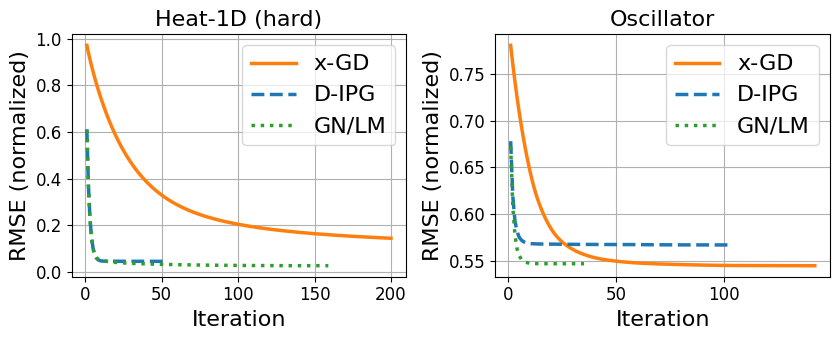

[saved] outputs_fair/figures_pdf/fig_rmse_vs_iters_with_baseline.pdf


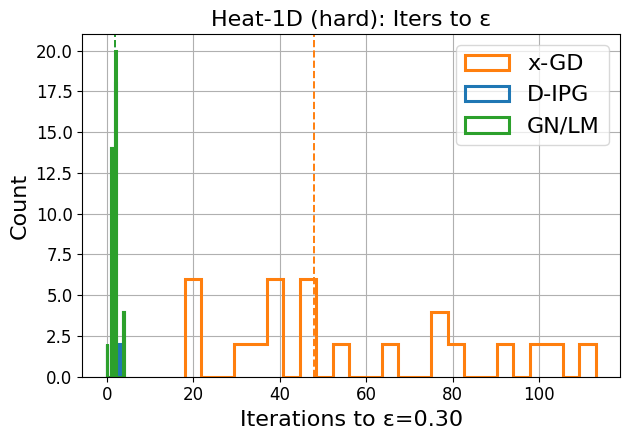

[saved] outputs_fair/figures_pdf/fig_heat_iters.pdf


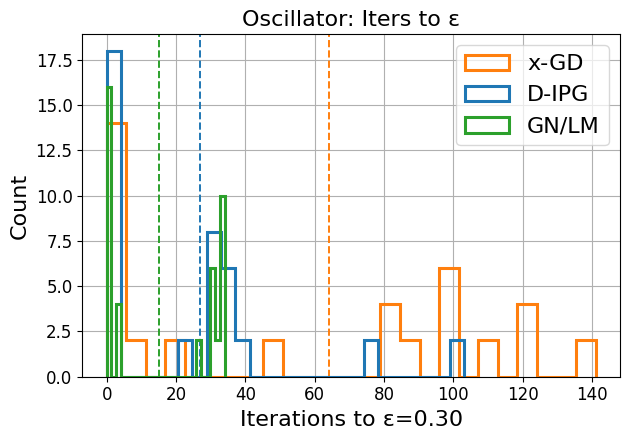

[saved] outputs_fair/figures_pdf/fig_osc_iters.pdf


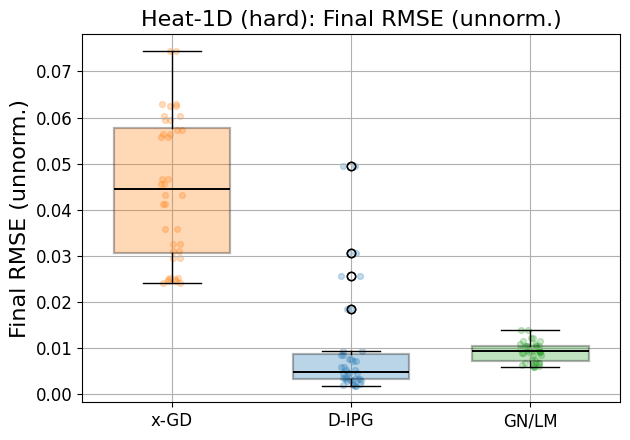

[saved] outputs_fair/figures_pdf/fig_heat_rmse.pdf


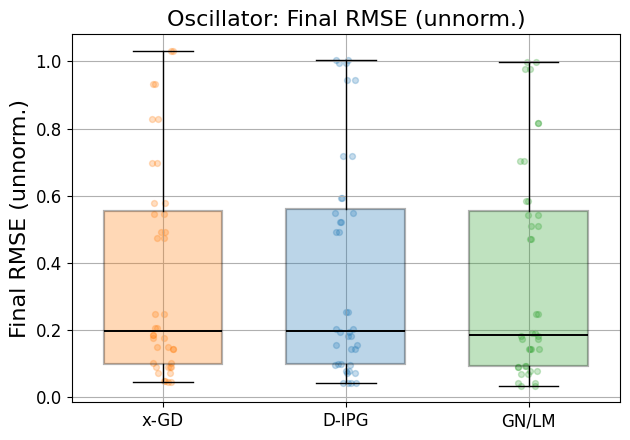

[saved] outputs_fair/figures_pdf/fig_osc_rmse.pdf


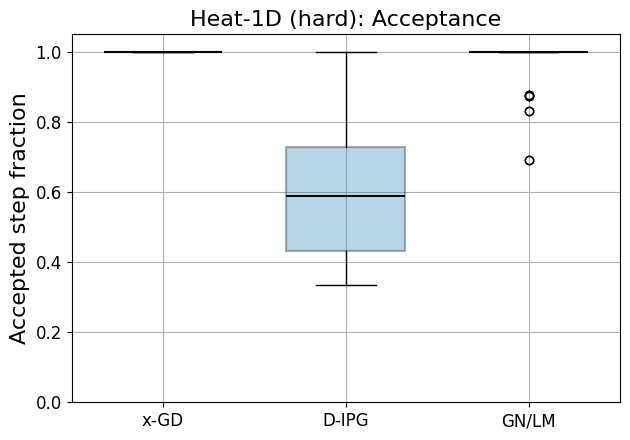

[saved] outputs_fair/figures_pdf/fig_heat_accept.pdf


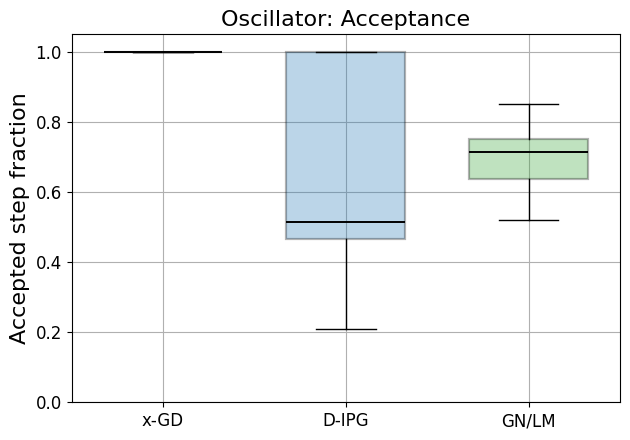

[saved] outputs_fair/figures_pdf/fig_osc_accept.pdf


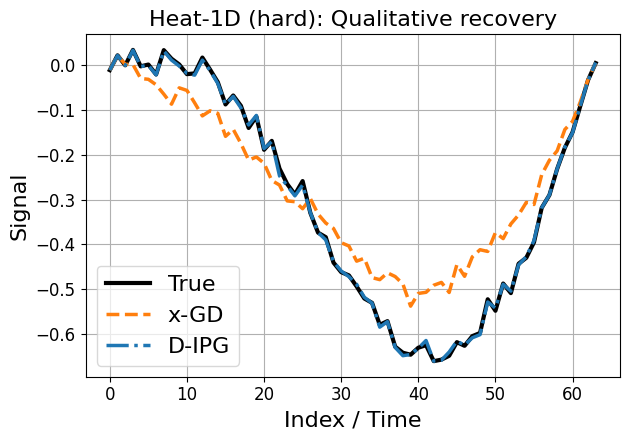

[saved] outputs_fair/figures_pdf/heat1d_qualitative_recovery.pdf
saved under /figures_pdf/

[Done]
 - outputs_fair/main_results.json
 - outputs_fair/models.pt
 - outputs_fair/test_sets.pt
 - figures under outputs_fair/figures_png
 - tables under  outputs_fair/tables


In [ ]:
def print_fairness():
    pack = dict(
        name="x-GD, D-IPG, GN/LM",
        armijo_c=CFG.backtrack_c,
        backtrack_halves=CFG.backtrack_halvings,
        relax_rho=CFG.relax_rho,
        step_init=dict(xgd=CFG.eta_xgd, dipg=CFG.alpha_dipg, gn=CFG.alpha_gn),
        eps_norm=CFG.eps_norm,
        projector="physics (clamp/bounds); identical across methods",
        stop_metric="RMSE in normalized y-space",
    )
    print("[Fairness] Protocol\n", json.dumps(pack, indent=2))

# ==== pipeline
set_seed(CFG.seed); ensure_out_dir(); print_fairness()

# data
heat = make_heat1d_dataset(); osc = make_osc_dataset()
Xtr_h,Ytrn_h = heat["train"]; Xva_h,Yvan_h = heat["val"]; Xte_h,Yten_h = heat["test"]; norm_h = heat["normalizer"]
Xtr_o,Ytrn_o = osc["train"];  Xva_o,Yvan_o = osc["val"];  Xte_o,Yten_o = osc["test"];  norm_o = osc["normalizer"]

# train
model_h, logs_h = train_deceptron("heat1d",
    (Xtr_h.to(CFG.device),Ytrn_h.to(CFG.device)), (Xva_h.to(CFG.device),Yvan_h.to(CFG.device)),
    CFG.heat1d_N, CFG.heat1d_N, learn_V=CFG.learn_V, activation=CFG.activation, leak=CFG.leak, detach_jcp_forward=False)

model_o, logs_o = train_deceptron("osc",
    (Xtr_o.to(CFG.device),Ytrn_o.to(CFG.device)), (Xva_o.to(CFG.device),Yvan_o.to(CFG.device)),
    5, CFG.osc_M, learn_V=CFG.learn_V, activation=CFG.activation, leak=CFG.leak, detach_jcp_forward=False)

# eval (same rho/Armijo/init for all)
heat_eval = eval_task("heat1d", model_h, Xte_h, Yten_h, norm_h, seeds=[0,1], projector=Projector("heat1d"), do_gn=True)
osc_eval  = eval_task("osc",    model_o, Xte_o, Yten_o, norm_o, seeds=[0,1], projector=Projector("osc"),    do_gn=True)

json.dump({"heat":heat_eval["summary"], "osc":osc_eval["summary"]},
          open(f"{CFG.out_dir}/main_results.json","w"), indent=2)
torch.save({
    "heat":{"state_dict":model_h.state_dict(),"in_dim":CFG.heat1d_N,"out_dim":CFG.heat1d_N,"activation":CFG.activation,"learn_V":CFG.learn_V},
    "osc":{"state_dict":model_o.state_dict(),"in_dim":5,"out_dim":CFG.osc_M,"activation":CFG.activation,"learn_V":CFG.learn_V},
}, f"{CFG.out_dir}/models.pt")
torch.save({"Xte_h":Xte_h,"Yten_h":Yten_h,"Xte_o":Xte_o,"Yten_o":Yten_o}, f"{CFG.out_dir}/test_sets.pt")

plot_mean_curves(heat_eval, osc_eval, model_h, Yten_h, model_o, Yten_o)
make_extra_figures(heat_eval, osc_eval, model_h, Xte_h, Yten_h, norm_h)

tab_dir = f"{CFG.out_dir}/tables"; os.makedirs(tab_dir, exist_ok=True)
open(f"{tab_dir}/main_comparison.json","w").write(json.dumps({'heat':heat_eval['summary'],'osc':osc_eval['summary']}, indent=2))
lines = ["Table (FAIR): Iterations-to-ε (mean±std), final RMSE (unnorm.), acceptance (mean)."]
for name, summ in [("Heat-1D (hard)", heat_eval["summary"]), ("Oscillator", osc_eval["summary"])]:
    row = [name]
    for m,label in [("xgd","x-GD"),("dipg","D-IPG"),("gn","GN/LM")]:
        if m in summ:
            s=summ[m]; row.append(f"{label}: iters {s['iters_mean']:.1f}±{s['iters_std']:.1f}, finalRMSE {s['final_rmse_mean']:.3f}, acc {s['accept_mean']:.2f}")
    lines.append(" | ".join(row))
open(f"{tab_dir}/table_main_fair.txt","w").write("\n".join(lines)+"\n")

print("\n[Done]")
print(" -", f"{CFG.out_dir}/main_results.json")
print(" -", f"{CFG.out_dir}/models.pt")
print(" -", f"{CFG.out_dir}/test_sets.pt")
print(" - figures under", f"{CFG.out_dir}/figures_png")
print(" - tables under ", f"{CFG.out_dir}/tables")


[Heat-1D] N=64, T=200, s=0.45 (≤0.5 good)
[heat1d ep 010] val_mse=5.7993e-02 jcp_w=0.00e+00
[heat1d ep 020] val_mse=5.6830e-02 jcp_w=0.00e+00
[heat1d ep 030] val_mse=5.5888e-02 jcp_w=0.00e+00
[heat1d ep 040] val_mse=5.5324e-02 jcp_w=0.00e+00
[heat1d ep 050] val_mse=5.4792e-02 jcp_w=0.00e+00
[heat1d ep 060] val_mse=5.4491e-02 jcp_w=0.00e+00
[Heat-1D] N=64, T=200, s=0.45 (≤0.5 good)
[Heat-1D] N=64, T=200, s=0.45 (≤0.5 good)
[heat1d ep 010] val_mse=1.6380e-01 jcp_w=0.00e+00
[heat1d ep 020] val_mse=1.6356e-01 jcp_w=0.00e+00
[heat1d ep 030] val_mse=1.6512e-01 jcp_w=0.00e+00
[heat1d ep 040] val_mse=1.6448e-01 jcp_w=0.00e+00
[heat1d ep 050] val_mse=1.6432e-01 jcp_w=0.00e+00
[heat1d ep 060] val_mse=1.6436e-01 jcp_w=0.00e+00
[Heat-1D] N=64, T=200, s=0.45 (≤0.5 good)
[Heat-1D] N=64, T=200, s=0.45 (≤0.5 good)
[heat1d ep 010] val_mse=5.0835e-02 jcp_w=0.00e+00
[heat1d ep 020] val_mse=5.1117e-02 jcp_w=3.56e-04
[heat1d ep 030] val_mse=5.1430e-02 jcp_w=5.78e-04
[heat1d ep 040] val_mse=5.1719e-02 jcp_w

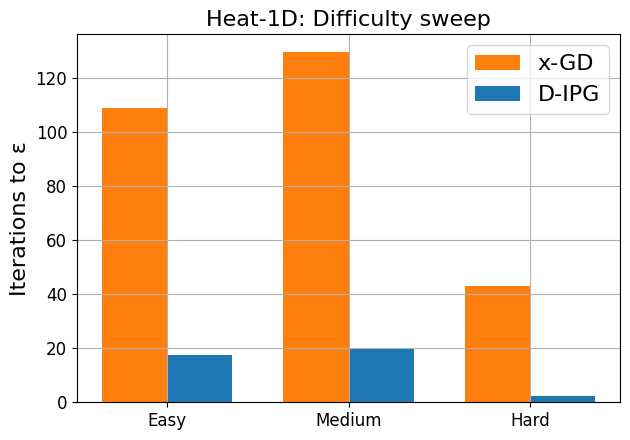

[saved] outputs_fair/figures_pdf/fig_heat_difficulty_sweep.pdf
[appendix] wrote CSV/MD under outputs_fair/appendix and figures under outputs_fair/figures_pdf


In [ ]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os

def _eval_quick_heat(model):
    h = make_heat1d_dataset()
    Xtr, Ytrn = h["train"]
    Xva, Yvan = h["val"]
    Xte, Yten = h["test"]
    nz = h["normalizer"]
    return eval_task("heat1d", model, Xte, Yten, nz, seeds=[0], projector=Projector("heat1d"), do_gn=False)["summary"]

def _style(ax, title=None, xlabel=None, ylabel=None, legend=True):
    for item in [ax.title, ax.xaxis.label, ax.yaxis.label]:
        item.set_fontfamily("sans-serif")
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily("sans-serif")
    if title:
        ax.set_title(title, fontsize=16, fontfamily="sans-serif")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=16, fontfamily="sans-serif")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=16, fontfamily="sans-serif")

    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    if legend:
        leg = ax.legend(
            frameon=True, facecolor="white", framealpha=0.75,
            fontsize=16, loc="best"
        )
        for text in leg.get_texts():
            text.set_fontfamily("sans-serif")



def _train_heat_override(**ov):
    saved = {k: getattr(CFG, k) for k in [
        "use_rec", "use_cyc", "use_spectral", "use_soft_tie",
        "use_jcp", "learn_V", "w_comp"
    ]}
    for k, v in ov.items():
        setattr(CFG, k, v)
    h = make_heat1d_dataset()
    Xtr, Ytrn = h["train"]
    Xva, Yvan = h["val"]
    model, _ = train_deceptron("heat1d",
        (Xtr.to(CFG.device), Ytrn.to(CFG.device)),
        (Xva.to(CFG.device), Yvan.to(CFG.device)),
        CFG.heat1d_N, CFG.heat1d_N, learn_V=CFG.learn_V)
    for k in ov.keys():
        setattr(CFG, k, saved[k])
    return model

abl = [
    ("−JCP", dict(use_jcp=False)),
    ("V=Wᵀ", dict(learn_V=False)),
    ("−rec/−cycle", dict(use_rec=False, use_cyc=False)),
    ("−comp", dict(w_comp=0.0))
]

rows = []
for name, ov in abl:
    m = _train_heat_override(**ov)
    s = _eval_quick_heat(m)
    rows.append((name, s))

app_dir = f"{CFG.out_dir}/appendix"
os.makedirs(app_dir, exist_ok=True)
with open(f"{app_dir}/appendix_ablation_normal_fair.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["ablation", "method", "iters_mean", "iters_std", "final_rmse_mean", "accept_mean"])
    for name, s in rows:
        for method in ["xgd", "dipg"]:
            w.writerow([
                name, method,
                s[method]["iters_mean"],
                s[method]["iters_std"],
                s[method]["final_rmse_mean"],
                s[method]["accept_mean"]
            ])

# --- Controlled +JCP vs −JCP
CFG.use_jcp = True
m_plus = _train_heat_override()
s_plus = _eval_quick_heat(m_plus)
CFG.use_jcp = False
m_minus = _train_heat_override()
s_minus = _eval_quick_heat(m_minus)
CFG.use_jcp = True

def _rjcp(model, X):
    vals = []
    for i in range(0, X.shape[0], 64):
        vals.append(float(jcp_penalty(model, X[i:i+64].to(CFG.device), probes=4).item()))
    return float(np.mean(vals))

heat_small = make_heat1d_dataset()
Xva_small = heat_small["val"][0]
rj_plus = _rjcp(m_plus, Xva_small)
rj_minus = _rjcp(m_minus, Xva_small)

table_md = (
    "| setting | iters-to-ε | final RMSE | accept rate | RJCP |\n|---|---:|---:|---:|---:|\n"
    f"| +JCP | {s_plus['dipg']['iters_mean']:.1f} | {s_plus['dipg']['final_rmse_mean']:.3f} | {s_plus['dipg']['accept_mean']:.2f} | {rj_plus:.3f} |\n"
    f"| −JCP | {s_minus['dipg']['iters_mean']:.1f} | {s_minus['dipg']['final_rmse_mean']:.3f} | {s_minus['dipg']['accept_mean']:.2f} | {rj_minus:.3f} |\n"
)
open(f"{app_dir}/appendix_ablation_jcp_fair.md", "w").write(table_md)
print("\nJCP comparison table:\n")
print(table_md)

# --- Heat-1D Difficulty Sweep
def _make_heat_only_test(Tsteps, n=20, noise=CFG.heat1d_noise):
    N, s = CFG.heat1d_N, CFG.heat1d_s
    X, Y = [], []
    for _ in range(n):
        u0 = _synth_ic_1d(N)
        traj = _heat1d_sim(u0, s, Tsteps, CFG.heat1d_kappa)
        y = traj[-1] + np.random.normal(0.0, noise, size=(N,))
        X.append(u0.astype(np.float32))
        Y.append(y.astype(np.float32))
    X = torch.tensor(np.stack(X))
    Y = torch.tensor(np.stack(Y))
    nz = ZNormalizer()
    nz.fit(Y)
    return X, nz.transform(Y)

proj = Projector("heat1d")
cases = [("Easy", 100), ("Medium", 150), ("Hard", 200)]
model_ref = m_plus

records = []
for name, T in cases:
    Xt, Yt = _make_heat_only_test(T, n=20)
    vals_x, vals_k = [], []
    for i in range(Xt.shape[0]):
        x_true = Xt[i:i+1].to(CFG.device)
        y_star = Yt[i:i+1].to(CFG.device)
        x0 = torch.zeros_like(x_true)
        ox = run_xgd(model_ref, x0, y_star, proj, CFG.max_iters, CFG.eta_xgd, CFG.relax_rho)
        ok = run_dipg(model_ref, x0, y_star, proj, CFG.max_iters, CFG.alpha_dipg, CFG.relax_rho)
        vals_x.append(iterations_to_eps(ox["rmse_hist"], CFG.eps_norm))
        vals_k.append(iterations_to_eps(ok["rmse_hist"], CFG.eps_norm))
    records.append((name, float(np.mean(vals_x)), float(np.mean(vals_k))))

print("\nHeat-1D Difficulty Sweep Results:\n")
print("| case | x-GD (iters->ε) | D-IPG (iters->ε) |\n|---|---:|---:|")
for name, vx, vk in records:
    print(f"| {name} | {vx:.2f} | {vk:.2f} |")

# --- Difficulty Sweep plot
labels = [r[0] for r in records]
x = np.arange(len(labels))
w = 0.36
xgd = [r[1] for r in records]
dipg = [r[2] for r in records]

fig, ax = plt.subplots(figsize=(6.4, 4.5))
ax.bar(x - w/2, xgd, width=w, label="x-GD", color=PAL["xgd"])
ax.bar(x + w/2, dipg, width=w, label="D-IPG", color=PAL["dipg"])
ax.set_xticks(x)
ax.set_xticklabels(labels)

_style(
    ax,
    title="Heat-1D: Difficulty sweep",
    ylabel="Iterations to ε",
    legend=True
)

fig.tight_layout()
path = f"{_ensure(f'{CFG.out_dir}/figures_pdf')}/fig_heat_difficulty_sweep.pdf"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"[saved] {path}")

print("[appendix] wrote CSV/MD under", f"{CFG.out_dir}/appendix", "and figures under", f"{CFG.out_dir}/figures_pdf")


In [ ]:
import os, numpy as np

assert "heat_eval" in globals() and "osc_eval" in globals(), "Run main eval first."

OUT_DIR = getattr(CFG, "out_dir", "outputs")
FAIR_DIR = os.path.join(OUT_DIR, "outputs_fair")
TAB_DIR = os.path.join(FAIR_DIR, "tables")
os.makedirs(TAB_DIR, exist_ok=True)

EPS = getattr(CFG, "eps_norm", 0.30)
BUDGET = getattr(CFG, "max_iters", 200)

def _median_iqr(vals):
    if len(vals) == 0:
        return (float("nan"), float("nan"), float("nan"))
    q25, q50, q75 = np.percentile(vals, [25, 50, 75])
    return float(q50), float(q25), float(q75)

def _per_method_stats(per_item):
    out = {}
    for m, runs in per_item.items():
        if not runs:
            continue
        iters = [r["iters_eps"] for r in runs]
        success = [(r["iters_eps"] < len(r["rmse_hist"])) for r in runs]
        ms_medians, tte = [], []
        for r in runs:
            t = r.get("times", [])
            if t:
                dt = np.diff([0.0] + t)
                ms_medians.append(1000.0 * np.median(dt))
                if r["iters_eps"] < len(r["rmse_hist"]):
                    tte.append(t[r["iters_eps"] - 1])
        med, q25, q75 = _median_iqr(iters)
        out[m] = {
            "iters_med": med,
            "iters_q25": q25,
            "iters_q75": q75,
            "success": float(np.mean(success)),
            "ms_per_iter_med": float(np.median(ms_medians)) if ms_medians else float("nan"),
            "time_to_eps_mean": float(np.mean(tte)) if tte else float("nan"),
        }
    return out

def _mk_text_table(title, stats):
    order = [k for k in ["xgd", "dipg", "gn"] if k in stats]
    name = {"xgd": "x-GD", "dipg": "D-IPG", "gn": "GN/LM"}
    lines = [
        title,
        "Method   | iters (median [IQR])  | Success | ms/iter (median) | Time-to-ε (mean s)",
        "---------+-----------------------+---------+------------------+-------------------",
    ]
    for k in order:
        s = stats[k]
        it_str = f"{s['iters_med']:.1f} [{s['iters_q25']:.1f}, {s['iters_q75']:.1f}]"
        lines.append(
            f"{name[k]:<9}| {it_str:<23} | {s['success']:.2f}    | {s['ms_per_iter_med']:.2f}           | {s['time_to_eps_mean']:.3f}"
        )
    return "\n".join(lines) + "\n"

heat_stats = _per_method_stats(heat_eval["per_item"])
osc_stats = _per_method_stats(osc_eval["per_item"])

tab_heat = _mk_text_table(f"Robustness & timing — Heat-1D (ε={EPS:.2f}, budget={BUDGET})", heat_stats)
tab_osc = _mk_text_table(f"Robustness & timing — Oscillator (ε={EPS:.2f}, budget={BUDGET})", osc_stats)

open(f"{TAB_DIR}/robust_timing_heat_fair.txt", "w").write(tab_heat)
open(f"{TAB_DIR}/robust_timing_osc_fair.txt", "w").write(tab_osc)

per_iter_txt = """Shared protocol and per-iteration compute
- All methods share: projector Π_C, Armijo (c, halvings), relaxation ρ, stopping in normalized y-space.
- Backtracking f-evals are shared and can add up to H extra f calls per accepted step.

Method  | Core per-iteration ops (excluding shared backtracking f-evals)
------- | -------------------------------------------------------------------------
x-GD    | 1 reverse-mode gradient ∇_x Φ
D-IPG   | 1 reverse-mode grad (for Armijo) + f + g  (propose y←y−αr, pull back via g)
GN/LM   | Solve (JᵀJ + λI) Δx = −Jᵀr by CG (each CG ≈ 1 JVP + 1 VJP)
"""
open(f"{TAB_DIR}/per_iter_compute_fair.txt", "w").write(per_iter_txt)

print(tab_heat)
print(tab_osc)
print(per_iter_txt)


Robustness & timing — Heat-1D (ε=0.30, budget=200)
Method   | iters (median [IQR])  | Success | ms/iter (median) | Time-to-ε (mean s)
---------+-----------------------+---------+------------------+-------------------
x-GD     | 49.0 [38.2, 80.0]       | 1.00    | 0.67           | 0.042
D-IPG    | 3.0 [2.0, 3.0]          | 1.00    | 1.31           | 0.002
GN/LM    | 3.0 [2.0, 3.0]          | 1.00    | 5.90           | 0.018

Robustness & timing — Oscillator (ε=0.30, budget=200)
Method   | iters (median [IQR])  | Success | ms/iter (median) | Time-to-ε (mean s)
---------+-----------------------+---------+------------------+-------------------
x-GD     | 65.0 [1.0, 101.2]       | 0.50    | 0.65           | 0.007
D-IPG    | 28.0 [1.0, 34.0]        | 0.45    | 1.87           | 0.001
GN/LM    | 16.0 [1.0, 33.2]        | 0.50    | 6.32           | 0.011

Shared protocol and per-iteration compute
- All methods share: projector Π_C, Armijo (c, halvings), relaxation ρ, stopping in normalized y-sp

In [ ]:
import sys, platform, hashlib, json, time, torch, numpy as np, os, glob

OUT_DIR  = getattr(CFG, "out_dir", "outputs")
FAIR_DIR = os.path.join(OUT_DIR, "outputs_fair")
TAB_DIR  = os.path.join(FAIR_DIR, "tables")
FIG_DIR  = os.path.join(FAIR_DIR, "figures")
os.makedirs(TAB_DIR, exist_ok=True)

def _sha256(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1<<20), b""):
            h.update(chunk)
    return h.hexdigest()

run_cfg = {
    "cfg": {k: (str(v) if isinstance(v, torch.dtype) else v) for k,v in asdict(CFG).items()},
    "base_seed": int(BASE_SEED),
    "eval_seeds": [0, 1],
    "eps_norm": getattr(CFG, "eps_norm", 0.30),
    "max_iters": getattr(CFG, "max_iters", 200),
    "fairness": {
        "rho": CFG.relax_rho, "armijo_c": CFG.backtrack_c, "halvings": CFG.backtrack_halvings,
        "step_inits": {"xgd": CFG.eta_xgd, "dipg": CFG.alpha_dipg, "gn": CFG.alpha_gn}
    },
}

env = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else None,
    "cudnn": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "device": CFG.device,
}

torch.save(model_h.state_dict(), os.path.join(OUT_DIR, "heat_model_state.pt"))
torch.save(model_o.state_dict(), os.path.join(OUT_DIR, "osc_model_state.pt"))
assert os.path.exists(os.path.join(OUT_DIR, "test_sets.pt")), "Missing test_sets.pt"

to_hash = []
to_hash += glob.glob(os.path.join(TAB_DIR, "*.txt"))
to_hash += glob.glob(os.path.join(TAB_DIR, "*.json"))
to_hash += glob.glob(os.path.join(FIG_DIR, "*.png")) + glob.glob(os.path.join(FIG_DIR, "*.svg"))
to_hash += [os.path.join(OUT_DIR, "heat_model_state.pt"),
            os.path.join(OUT_DIR, "osc_model_state.pt"),
            os.path.join(OUT_DIR, "test_sets.pt")]
hashes = {os.path.relpath(p, OUT_DIR): _sha256(p) for p in to_hash if os.path.exists(p)}

rng = {"torch_cpu": torch.get_rng_state().tolist()}
if torch.cuda.is_available():
    rng["torch_cuda_all"] = [s.tolist() for s in torch.cuda.get_rng_state_all()]

manifest = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "env": env,
    "run_cfg": run_cfg,
    "hashes": hashes,
    "main_results_json": os.path.join(OUT_DIR, "outputs_fair", "tables", "main_comparison.json"),
    "robust_timing_heat_txt": os.path.join(OUT_DIR, "outputs_fair", "tables", "robust_timing_heat_fair.txt"),
    "robust_timing_osc_txt": os.path.join(OUT_DIR, "outputs_fair", "tables", "robust_timing_osc_fair.txt"),
    "rng_state": rng,
}
with open(os.path.join(OUT_DIR, "repro_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print("wrote manifest to", os.path.join(OUT_DIR, "repro_manifest.json"))


wrote manifest to outputs_fair/repro_manifest.json


In [ ]:
#!/usr/bin/env bash
#set -e
# 1) env
#python -c "import torch,sys;print('python',sys.version.split()[0]);print('torch',torch.__version__);print('cuda',torch.version.cuda)"
# 2) run notebook end-to-end (or python script) producing outputs_fair/*
#    (If you have the .py driver, use it; else nbconvert)
# jupyter nbconvert --to notebook --execute deceptrons_v2_1.ipynb --output executed.ipynb
# 3) verify hashes match the manifest
#python - <<'PY'
#import os, json, hashlib, sys
#out="outputs"; mf=os.path.join(out,"repro_manifest.json")
#j=json.load(open(mf))
#def sha(p):
#    h=hashlib.sha256()
#    with open(p,"rb") as f:
#        for c in iter(lambda:f.read(1<<20), b""): h.update(c)
#    return h.hexdigest()
#bad=[]
#for rel, expect in j["hashes"].items():
#    p=os.path.join(out,rel)
#    if not os.path.exists(p): bad.append((rel,"MISSING"))
#    else:
#        got=sha(p)
#        if got!=expect: bad.append((rel,"MISMATCH"))
#print("VERIFY:", "OK" if not bad else ("ISSUES: "+str(bad)))
#PY


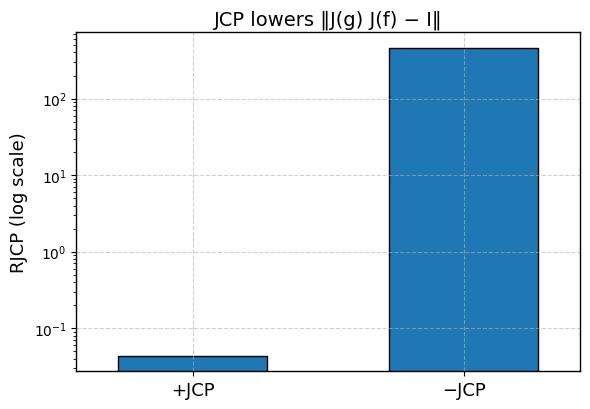

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["+JCP", "−JCP"]
vals = [rj_plus, rj_minus]

fig, ax = plt.subplots(figsize=(6.0, 4.2))
x = np.arange(len(labels))
width = 0.55
ax.bar(x, vals, width=width, color="#1f77b4", edgecolor="black", linewidth=1.0)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel("RJCP (log scale)", fontsize=13)
ax.set_title("JCP lowers ‖J(g) J(f) − I‖", fontsize=14, pad=6)

ax.grid(True, linestyle="--", alpha=0.6)
for s in ax.spines.values():
    s.set_visible(True)
    s.set_linewidth(1.0)
    s.set_color("black")

ax.margins(x=0.1)
fig.tight_layout()
fig.savefig("outputs_fair/fig_rjcp_consistency.pdf", bbox_inches="tight")
plt.show()


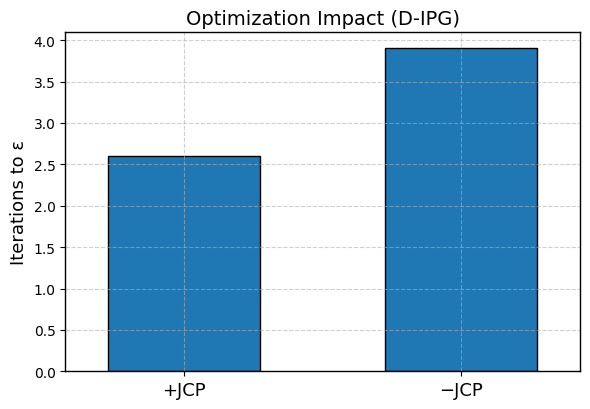

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

iters_plus  = s_plus["dipg"]["iters_mean"]
iters_minus = s_minus["dipg"]["iters_mean"]

labels = ["+JCP", "−JCP"]
vals = [iters_plus, iters_minus]
x = np.arange(len(labels))
width = 0.55

fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.bar(x, vals, width=width, color="#1f77b4", edgecolor="black", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel("Iterations to ε", fontsize=13)
ax.set_title("Optimization Impact (D-IPG)", fontsize=14, pad=6)

ax.grid(True, linestyle="--", alpha=0.6)
for s in ax.spines.values():
    s.set_visible(True)
    s.set_linewidth(1.0)
    s.set_color("black")

ax.margins(x=0.1)
fig.tight_layout()
fig.savefig("outputs_fair/fig_optimization_impact.pdf", bbox_inches="tight")
plt.show()


RJCP Diagnostic figure (given below) is added in final version (addressing reviewer's suggestions)

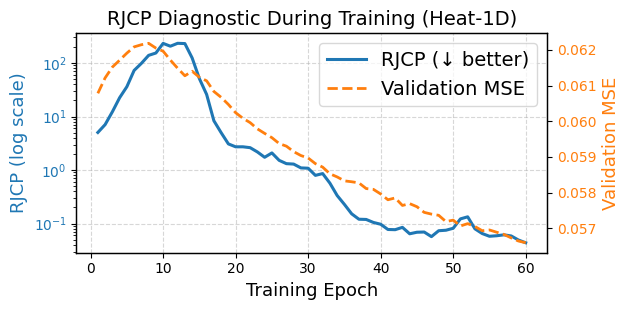

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

logs = logs_h

rjcp_vals = np.array(logs["jcp"])
val_mse   = np.array(logs["val_mse"])
epochs = np.arange(1, len(val_mse) + 1)

fig, ax1 = plt.subplots(figsize=(6.4, 3.2))

color_rjcp = PAL["dipg"]
color_mse  = PAL["xgd"]

ax1.plot(epochs, rjcp_vals, color=color_rjcp, linewidth=2.2, label="RJCP (↓ better)")
ax1.set_yscale("log")
ax1.set_xlabel("Training Epoch", fontsize=13)
ax1.set_ylabel("RJCP (log scale)", color=color_rjcp, fontsize=13)
ax1.tick_params(axis="y", labelcolor=color_rjcp)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(epochs, val_mse, color=color_mse, linewidth=2.0, linestyle="--", label="Validation MSE")
ax2.set_ylabel("Validation MSE", color=color_mse, fontsize=13)
ax2.tick_params(axis="y", labelcolor=color_mse)

lines, labels = [], []
for ax in [ax1, ax2]:
    for l in ax.get_lines():
        lines.append(l)
        labels.append(l.get_label())
ax1.legend(lines, labels, loc="upper right", frameon=True, facecolor="white", framealpha=0.75, fontsize=14)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_color("black")
for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_color("black")

plt.title("RJCP Diagnostic During Training (Heat-1D)", fontsize=14)
fig.tight_layout()
fig.savefig("outputs_fair/rjcp_diagnostic.pdf", bbox_inches="tight")
plt.show()